In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=8, bn=True, normalise=False)
device = torch.device("mps")
weights_path = TRAINING_RESULTS/'high_mass'/'run_060426_155322'/'best_model_weights.pth'
#weights_path = TRAINING_RESULTS/'ext_high_mass'/ 'good_runs' /'run_090326_150123'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Plotter

In [37]:
results_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_165434'/'results.pt'
results = torch.load(results_path)
iters, train_loss, train_soft_acc, val_soft_acc,\
          train_hard_acc, val_hard_acc, test_soft_acc, test_hard_acc= results

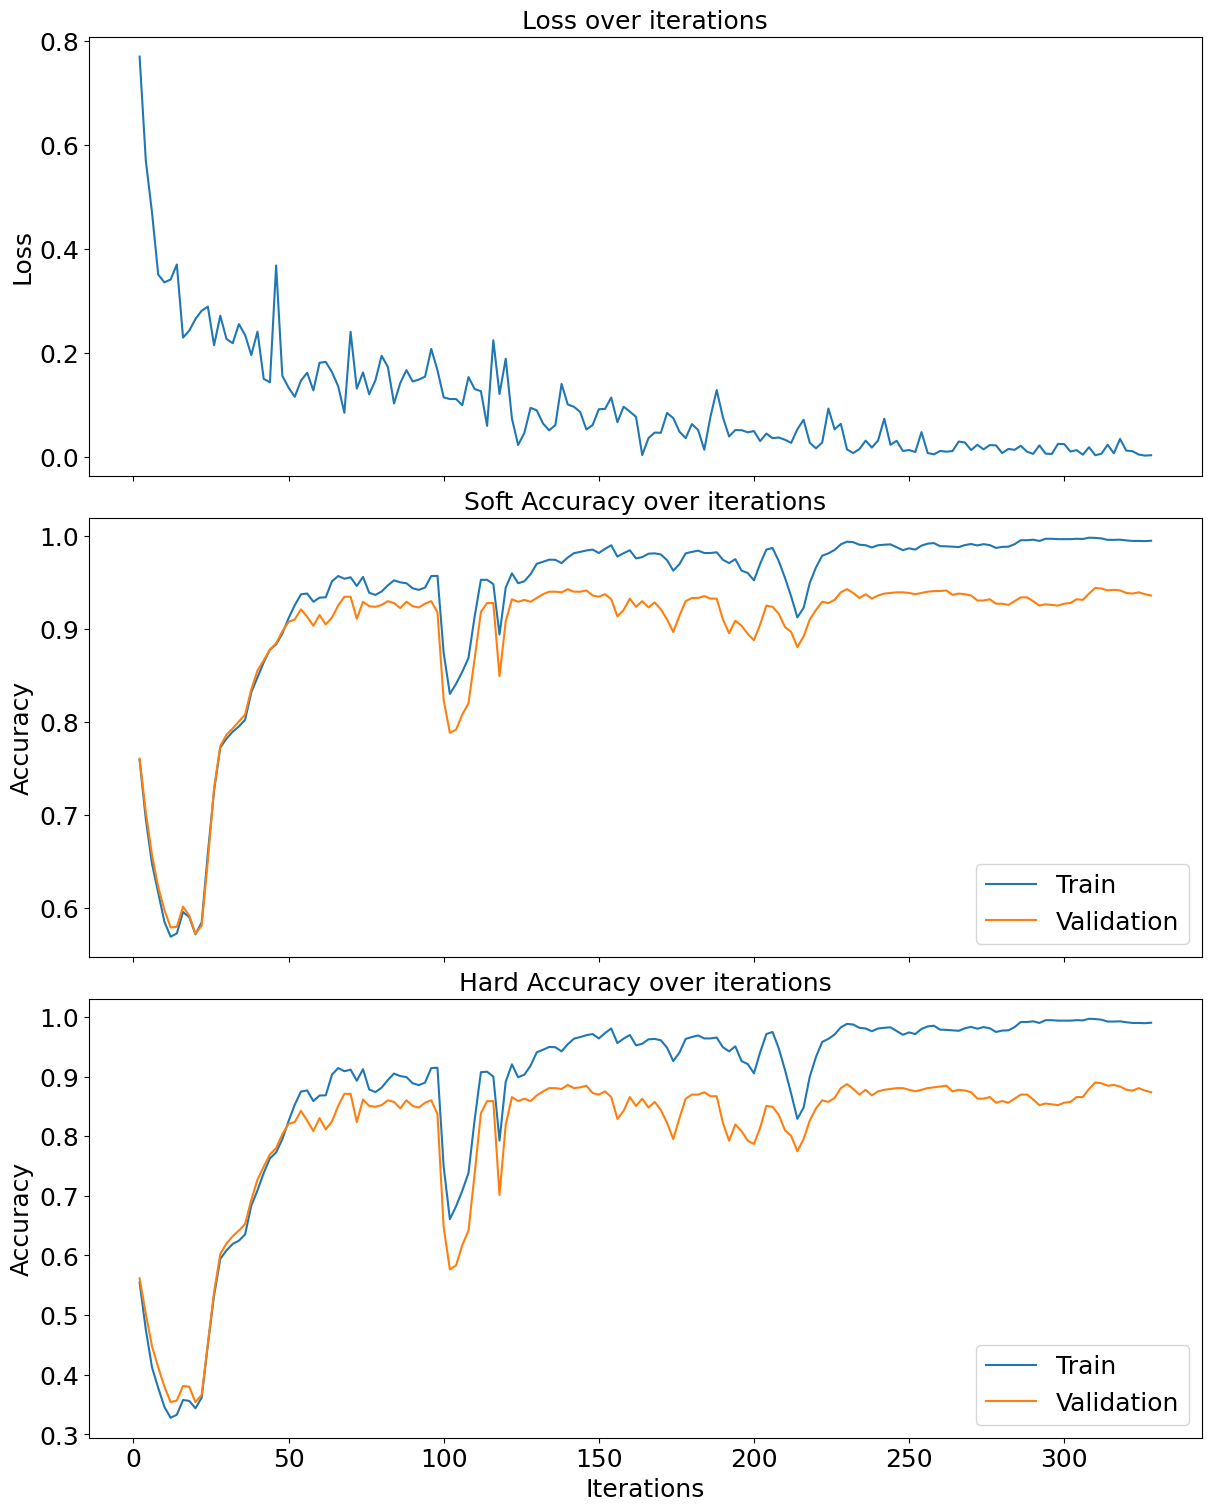

In [38]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 15), constrained_layout=True)

axes[0].plot(iters[:len(train_loss)], train_loss)
axes[0].set_title("Loss over iterations",  fontsize=18)
axes[0].set_ylabel("Loss",  fontsize=18)
axes[0].tick_params(axis='y', labelsize=18)

axes[1].plot(iters[:len(train_soft_acc)], train_soft_acc)
axes[1].plot(iters[:len(val_soft_acc)], val_soft_acc)
axes[1].set_title("Soft Accuracy over iterations", fontsize=18)
axes[1].set_ylabel("Accuracy",  fontsize=18)
axes[1].legend(["Train", "Validation"],  fontsize=18)
axes[1].tick_params(axis='y', labelsize=18)

axes[2].plot(iters[:len(train_hard_acc)], train_hard_acc)
axes[2].plot(iters[:len(val_hard_acc)], val_hard_acc)
axes[2].set_title("Hard Accuracy over iterations",  fontsize=18)
axes[2].set_xlabel("Iterations",  fontsize=18)
axes[2].set_ylabel("Accuracy",  fontsize=18)
axes[2].legend(["Train", "Validation"],  fontsize=18)

axes[2].tick_params(axis='x', labelsize=18)
axes[2].tick_params(axis='y', labelsize=18)
plt.show()

## Confusion matrix

In [3]:
dataset = LISADataset(training_hm_dataset_path)

N = len(dataset)
train_size = int(0.7 * N)
val_size   = int(0.2 * N)
test_size  = N - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator)

In [4]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1].to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

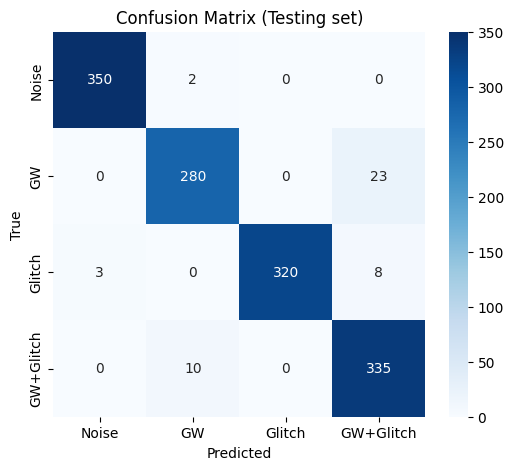

In [5]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [39]:
np.where((true_class == 2)&(pred_class == 2))[0][0:20]

array([ 4,  8, 13, 14, 18, 21, 22, 23, 25, 27, 28, 35, 41, 43,
       45, 49, 52, 53, 57, 61])

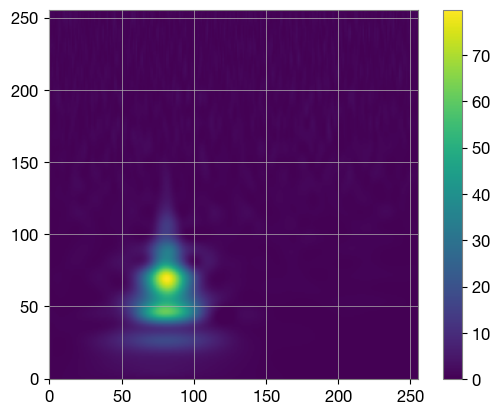

True label: tensor([0., 1.])
Sim index: 12
Time index: 1


In [33]:
image, label, sim_index, time_index = test_dataset[41]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

## Time centering

In [15]:
from helpers.qtransform import *
from helpers.simulation import *

MASS_CATEGORY = 'high_mass'  # 'low_mass', 'high_mass', 'ext_high_mass'
SPEC = SPECS[MASS_CATEGORY]

RESOLUTION = 256
REPRESENTATION = 'qscan'  # 'qscan' or 'varqscan'

def run_one_sample(args):
    tcen, X, Y, Z = args
    tdi_dict = make_tdi_dict(X, Y, Z)
    
    event = {'t_inj': PIPE['t_inj'] - tcen}

    QT = np.zeros((RESOLUTION, RESOLUTION, 3))
    for channel in ['A', 'E', 'T']:
        if REPRESENTATION == 'varqscan':
            t_arr, f_arr, data = varq_transform(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                                        frange=SPEC['frange'], trange=SPEC['trange'], Qvals=SPEC['Qvals'])
        elif REPRESENTATION == 'qscan':
            t_arr, f_arr, data = generate_qscan(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                             frange=SPEC['frange'], trange=SPEC['trange'], Q=SPEC['Q'])

        QT[:, :, ['A', 'E', 'T'].index(channel)] = data

    return QT, t_arr, f_arr

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [40]:
with h5py.File(glitch_hm_dataset_path, 'r') as f:
    X = f['X'][sim_index]
    Y = f['Y'][sim_index]
    Z = f['Z'][sim_index]

In [41]:
tcen_arr = np.linspace(-3, 3, 25)*3600

image_arr = np.zeros((len(tcen_arr), 256, 256, 3))
for i, tcen in enumerate(tcen_arr):
    args = (tcen, X, Y, Z)
    QT, tarr, farr = run_one_sample(args)
    image_arr[i, :, :, :] = QT

image_arr = torch.tensor(image_arr, dtype=torch.float32)
image_arr = image_arr.permute(0, 3, 1, 2)

In [42]:
with torch.no_grad():
    outputs = model(image_arr.to(device).contiguous())
    probs = torch.sigmoid(outputs)

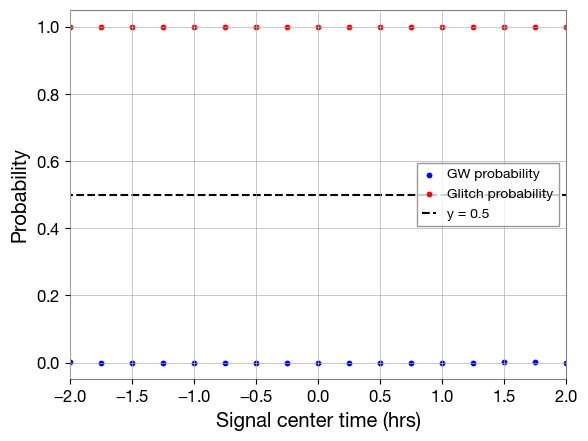

In [43]:
gw_prob = probs[:, 0].detach().cpu().numpy()
glitch_prob = probs[:, 1].detach().cpu().numpy()
tcen_act = 1.87*3600
plt.scatter(tcen_arr/3600, gw_prob, color='blue', label='GW probability', s=10)
plt.scatter(tcen_arr/3600, glitch_prob, color='red', label='Glitch probability', s=10)
plt.hlines(y=[0.5], xmin=-3, xmax=3, color='black', linestyle='dashed', label='y = 0.5')
plt.xlabel('Signal center time (hrs)')
plt.ylabel('Probability')
plt.legend(fontsize=10)
plt.xlim(-2,2)
#plt.ylim(-0.5, 1.2)
plt.show()